<a href="https://colab.research.google.com/github/Albin78/Data_Analysis_Project/blob/main/Computer__Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Computer Vision

## 0. Computer Vision libraries in PyTorch
* torchvision library for computer vision
* torchvision.datasets - gets datasets and data loading functions for computing vision
* torchvision.models - get pretrained computer vision models
* torchvision.transforms - functions for manipulate vision data(image) to suitable for ML model
* torch.utils.data.Dataset - base dataset class for Pytorch
* torch.utils.data.DataLoader - creates a Python iterble over a dataset


In [ ]:
# import pytorch
import torch
from torch import nn

#import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

#import matplotlib
import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


## 1.Getting  a dataset
* FashinMNIST is the dataset using from torchvision.datasets



In [ ]:
# set up training data
train_data = datasets.FashionMNIST(
    root='data',  # where to download data
    train = True,  # ensures that the training dataset
    download = True,
    transform = torchvision.transforms.ToTensor(),  # converting to tensors
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train=False,
    download=True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.72MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.26MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
#seeing first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

## 1.1 Checking input and output shape of data

In [ ]:
#checking shape
print(f'Image Shape:{image.shape} -> [color_channels,height,width]')
print(f'Label:{class_name[label]}')

Image Shape:torch.Size([1, 28, 28]) -> [color_channels,height,width]
Label:Ankle boot


## 1.2  Visualizing the data

Image Shape:torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

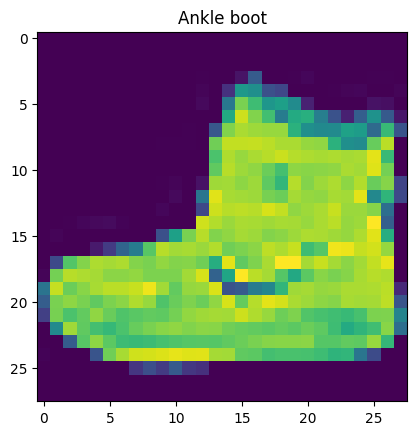

In [ ]:
image, label = train_data[0]
print(f'Image Shape:{image.shape}')
image
plt.imshow(image.squeeze())
plt.title(class_name[label])

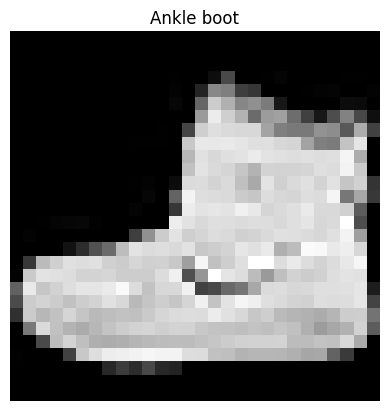

In [ ]:
plt.imshow(image.squeeze(), cmap='gray')
plt.axis(False)
plt.title(class_name[label]);

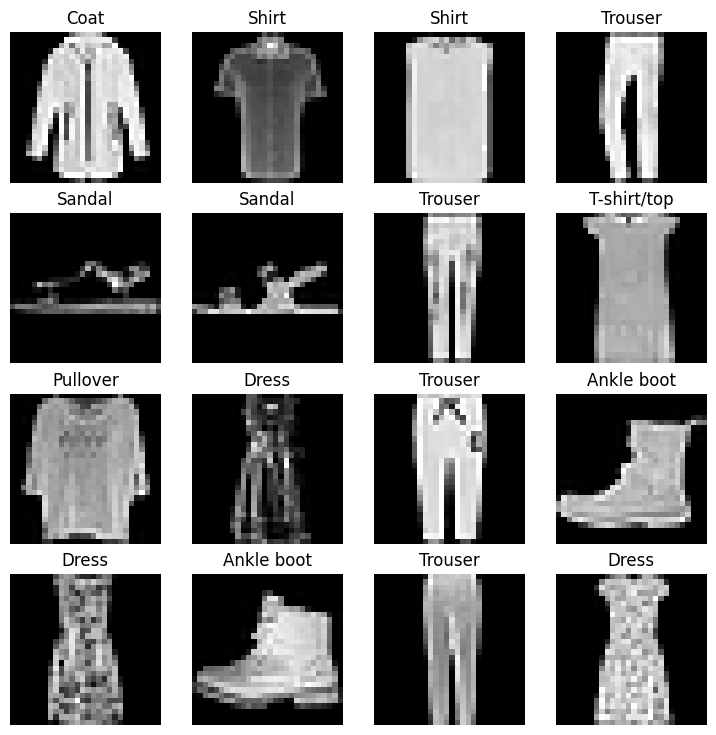

In [ ]:
# plotting more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols =4, 4
for i in range(1, rows*cols + 1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap='gray')
  plt.title(class_name[label])
  plt.axis(False)

In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

##2. prepare DataLoader
  Now the data is in the form of PyTorch Datasets

* Data Loader turn the datsets to python iterable
* Turn the data to batches or mini-batches

The reason for turning data into batches :

1. It is more computationally efficient,ie, the computing hardware may not be look (store memory) of 60000 images at one hit. So dividing into batches to
32 (can change the value)images at a time

2. Gives nueral network more chances to update its gradients per epoch



In [ ]:
# using dataloader specifying batch size for train_data and test_data
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_data,
                        batch_size=32,
                        shuffle=True)
test_loader = DataLoader(dataset=test_data,
                         batch_size=32,
                         shuffle=False)
train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7f3fa1446810>,
 <torch.utils.data.dataloader.DataLoader at 0x7f3fa130cb90>)

In [ ]:
# Checkig the created loaders
print(f'DataLoaders:{train_loader, test_loader}')
print(f'Length of Train Data Loader:{len(train_loader)} batches of {train_loader.batch_size}...')
print(f'Length of Test Data Loader:{len(test_loader)} batches of {test_loader.batch_size}....')

DataLoaders:(<torch.utils.data.dataloader.DataLoader object at 0x7f3fa1446810>, <torch.utils.data.dataloader.DataLoader object at 0x7f3fa130cb90>)
Length of Train Data Loader:1875 batches of 32...
Length of Test Data Loader:313 batches of 32....


In [ ]:
# checking inside train data loader
train_features_batch, train_labels_batch = next(iter(train_loader))
train_features_batch.shape, train_labels_batch.shape, len(train_features_batch)

(torch.Size([32, 1, 28, 28]), torch.Size([32]), 32)

Image Size:torch.Size([1, 28, 28])
Label:8, Label Size:torch.Size([])


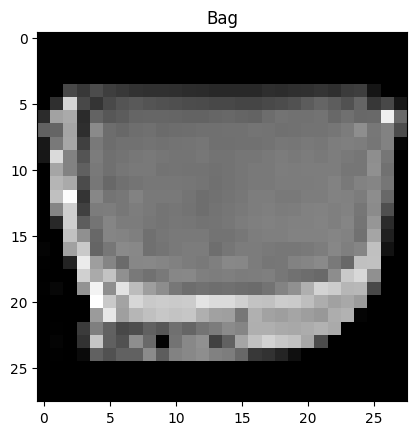

In [ ]:
# visualising a batch
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_name[label])
print(f'Image Size:{img.shape}')
print(f'Label:{label}, Label Size:{label.shape}')

# 3. Craeting a baseline model
 * A baseline model is a simple model you will try and improve upon with subsequent models/experiments, in simple words it start simply and add complecity when neccessary

In [ ]:
# create a flatten model
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch

# flatten the sample
output = flatten_model(x)  # performs forward pass
print(f'Shape before flattening:{x.shape}')
print(f'Shape after flattening:{output.shape}')

Shape before flattening:torch.Size([32, 1, 28, 28])
Shape after flattening:torch.Size([32, 784])


In [ ]:
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
from torch import nn
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape:int,
               output_shape:int, hidden_units:int):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self,x):
    x = self.layer(x)
    return x

torch.manual_seed(42)
model_0 = FashionMNISTModel(input_shape=784,  # this is 28 * 28
                            output_shape =len(class_name),
                            hidden_units = 10)

model_0.to('cpu')
model_0



FashionMNISTModel(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
model_0.state_dict()

OrderedDict([('layer.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.3130, -0.0118,
   

In [ ]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)


tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## 3.1 setup loss and optimizer

* As working in multi class data, loss function will be nn.CrossEntropyLoss()
* Optimizer - SGD


In [ ]:
a= torch.tensor([[1,2],[3,4]])
b = torch.tensor([[2,1],[3,4]])

In [ ]:
torch.eq(b,torch.tensor([[2,1],[3,4]])).sum()

tensor(4)

In [ ]:
def accuracy_fn(y_true, y_pred):
  correct = (y_true==y_pred).sum().float()
  acc = correct * 100 / len(y_pred)
  return acc

In [ ]:
# seting loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
loss_fn, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

### 3.2 Creating function to time the experiment

* ML is very experimental, two main things often track on:
1. Model's performance (loss and accuracy values)
2. How fast it runs

In [ ]:
from timeit import default_timer as timer
def print_train_time(start:float,
                     end:float,
                     device:torch.device=None):
  """Prints difference btwn start and end time."""
  total_time = end - start
  print(f'Train Time on {device}: {total_time:3f} seconds')
  return total_time


In [ ]:
start_time = timer()
# ....
end_time = timer()
#...
print_train_time(start = start_time, end=end_time, device='cpu')

Train Time on cpu: 0.000040 seconds


4.0207000012060234e-05

## 3.3 Training loop and training a model on batches of data

1. Loop through epoch
2. Loop through training batches, perform training steps, calculate train loss
per batch
3. Loop through testing batches, perform testing steps, calculate the test loss
per batch
4. printing the process involved
5. Time it all


In [ ]:
for batch, (X,y) in enumerate(train_loader):
  print(batch)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
for X, y in test_loader:
  print(len(X))

32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
16


In [ ]:
# import tqdm for progress bar
from tqdm.auto import tqdm

# set seed and start timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# epochs(small for faster training)
epochs = 3

#create training and testing loop
for epoch in tqdm(range(epochs)):
  print(f'Epoch:{epoch}\n--')
  #training
  train_loss = 0
  # Add a loop through the training batches
  for batch, (X,y) in enumerate(train_loader):
    model_0.train()
    # 1.forward pass
    y_pred = model_0(X)

    #2. calculate loss
    loss = loss_fn(y_pred,y)
    train_loss += loss

    #3. optimizer zer_grad
    optimizer.zero_grad()

    #4. Backpropogation
    loss.backward()

    #5.optimizer step
    optimizer.step()

    if batch % 400 == 0:
      print(f'Looked at {batch * len(X)}/{(len(train_loader.dataset))} samples')

    #Divide total train loss by length of train dataloader
  train_loss /= len(train_loader)

  ## Testing
  test_loss, test_acc = 0,0
  model_0.eval()
  with torch.inference_mode():
    for X,y  in test_loader:
      test_pred = model_0(X)
      test_loss += loss_fn(test_pred, y)

      #accuracy
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    # calculate test loss average per batch
    test_loss /= len(test_loader)

    #calculate tess acc average
    test_acc /= len(test_loader)

  print(f'\nTrain Loss: {train_loss} | Test Loss: {test_loss:.4f} | Test Accuracy:{test_acc:2f}%')

# calaculate train time
train_time_end_on_cpu = timer()
toal_train_time_model_0 = print_train_time(start = train_time_start_on_cpu,
                 end = train_time_end_on_cpu,
                 device = str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
--
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.5903891921043396 | Test Loss: 0.5095 | Test Accuracy:82.038734%
Epoch:1
--
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.4763319194316864 | Test Loss: 0.4799 | Test Accuracy:83.196884%
Epoch:2
--
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.4550333023071289 | Test Loss: 0.4766 | Test Accuracy:83.426521%
Train Time on cpu: 31.995403 seconds


In [ ]:
str(next(model_0.parameters()).device)

'cpu'

## 4. Make predictions and get model_0 predictions


In [ ]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """ Returns a dictionary containing the results of model predicting on data loader """
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      # make predictions
      y_pred = model_0(X)

      # accumulate loss and acc in per batch
      #loss
      loss += loss_fn(y_pred, y)

      # accuracy
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))
    # scale the loss and acc  to find average loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)
  return {'model_name':model.__class__.__name__, # only works when model created using class
          'model_loss':loss.item(),
          'model_acc': float(acc)}

  # calculate model_0 on test dataloader

model_0_results = eval_model(model=model_0, data_loader=test_loader,
                               loss_fn = loss_fn, accuracy_fn = accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42652130126953}

In [ ]:
!nvidia-smi

Sat Apr 19 07:58:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
torch.cuda.is_available()

True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 4. Building a better model with non-linearity



In [ ]:
classes = train_data.classes

In [ ]:
# create a model with non-linear and linear layers
class FashionMNISTV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape:int):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=output_shape),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x:torch.Tensor):
    return self.layer(x)

torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_1 = FashionMNISTV1(input_shape=784,hidden_units=10,output_shape=len(classes))
model_1.to(device)

FashionMNISTV1(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [ ]:
model_1.state_dict()

OrderedDict([('layer.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
                     device='cuda:0')),
             ('layer.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163], device='cuda:0')),
             ('layer.3.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0

In [ ]:
next(model_1.parameters()).device

device(type='cuda', index=0)

## 4.1 setting up loss function,optimizer and evaluation metrics for model_1

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
# accuracy is already defined as accuracy_fn

# 4.2 Taking custom functions for training and testing loops

* creating a function for train - `train_mode()`
* creating a function for test - `test_mode()`

In [ ]:
def train_mode(model:torch.nn.Module, data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer,
               accuracy_fn, device:torch.device):
  """Performs a training with model trying to learn on data_loader"""
  train_loss, train_acc = 0,0
  model.train()
  for batch, (X,y) in enumerate(data_loader):
    # target device
    X,y = X.to(device), y.to(device)

    # forward
    y_pred = model(X)
    #loss calculation
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # accuracy
    accuracy = accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    train_acc += accuracy

    #backpropgation and gradient descent
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if batch % 400 == 0:
      print(f'Looked at{batch * len(X)}/{len(data_loader.dataset)}samples')

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f'Train Loss:{train_loss:.4f}, Train accuracy:{train_acc:.2f}%')

In [ ]:
def test_mode(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:nn.Module, accuracy_fn,
              device:torch.device):
  """Performs Testing Loop step on model going over data loader"""
  test_loss, test_acc = 0, 0
  #putting model on eval mode
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      # Setting to target device
      X, y = X.to(device), y.to(device)
      # Forward pass
      test_pred = model(X)
      #Taking loss during testing
      test_loss += loss_fn(test_pred, y)
      #Test Accuarcy
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))  # using argmax for logits -> prediction probabilities -> labels

    #Adjust metrices and print out
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f'Test Loss: {test_loss:.4f} | Test Accuracy:{test_acc:.2f}%')



In [ ]:
# checking the model with the train function
# train_mode(model=model_0,data_loader=train_loader,
#            loss_fn=loss_fn,optimizer=optimizer,
#            accuracy_fn=accuracy_fn, time_cal=print_train_time,
#            device=str(next(model_0.parameters()).device), epochs =3)

In [ ]:
# test_mode(model=model_0, data_loader=test_loader,
#           loss_fn=loss_fn, accuracy_fn=accuracy_fn,
#           device=str(next(model_0.parameters()).device),
#           time_cal = print_train_time)

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42652130126953}

In [ ]:
toal_train_time_model_0

31.99540310499998

In [ ]:
torch.manual_seed(42)
#Measuring time
from timeit import default_timer as timer
train_time_start = timer()
#seting epochs
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f'Epoch{epoch}\n------')

  #Create a training and evaluation loop using custom functions train_mode() and test_mode()
  train_mode(model=model_1,
             data_loader=train_loader,
             loss_fn=loss_fn, accuracy_fn=accuracy_fn,
             optimizer=optimizer, device=str(next(model_1.parameters()).device))

  test_mode(model=model_1, data_loader=test_loader,
            loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=str(next(model_1.parameters()).device))

train_time_end = timer()
total_time_taken = print_train_time(train_time_start, train_time_end, str(next(model_1.parameters()).device))



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch0
------
Looked at0/60000samples
Looked at12800/60000samples
Looked at25600/60000samples
Looked at38400/60000samples
Looked at51200/60000samples
Train Loss:1.0920, Train accuracy:61.34%
Test Loss: 0.9564 | Test Accuracy:65.00%
Epoch1
------
Looked at0/60000samples
Looked at12800/60000samples
Looked at25600/60000samples
Looked at38400/60000samples
Looked at51200/60000samples
Train Loss:0.7810, Train accuracy:71.93%
Test Loss: 0.7223 | Test Accuracy:73.91%
Epoch2
------
Looked at0/60000samples
Looked at12800/60000samples
Looked at25600/60000samples
Looked at38400/60000samples
Looked at51200/60000samples
Train Loss:0.6703, Train accuracy:75.94%
Test Loss: 0.6850 | Test Accuracy:75.02%
Train Time on cuda:0: 28.204375 seconds


In [ ]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn, device:torch.device):
  """ Returns a dictionary containing the results of model predicting on data loader """
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      # make predictions
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      # accumulate loss and acc in per batch
      #loss
      loss += loss_fn(y_pred, y)

      # accuracy
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))
    # scale the loss and acc  to find average loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)
  return {'model_name':model.__class__.__name__, # only works when model created using class
          'model_loss':loss.item(),
          'model_acc': float(acc)}

  # calculate model_0 on test dataloader

# model_0_results = eval_model(model=model_0, data_loader=test_loader,
#                                loss_fn = loss_fn, accuracy_fn = accuracy_fn,
#                              device=str(next(model.parameters()).device))
# model_0_results

In [ ]:
# Get model_1 results
model_1_results = eval_model(model=model_1, data_loader=test_loader,
                             loss_fn=loss_fn,accuracy_fn=accuracy_fn,
                             device=str(next(model_1.parameters()).device))
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996612548828}

In [ ]:
model_0_results = eval_model(model=model_0, data_loader=test_loader,
                             loss_fn=loss_fn, accuracy_fn=accuracy_fn,
                             device=str(next(model_0.parameters()).device))
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42652130126953}

## 5. Building a Convolutional Neural Network

* CNN's are knwon as ConvNets.
* CNN's are known for their capabilities of learning patterns in visual data

In [ ]:
class_name = train_data.classes
device = 'cuda' if torch.cuda.is_available() else 'cpu'
class_name, device

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 'cuda')

In [ ]:
# Building CNN model
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape:int, hidden_units:int,
               output_shape:int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        # create conv layer
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),  # these are hyperparameters of conv2d
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features = output_shape))

  def forward(self, x):
    x = self.conv_block_1(x)
    print(f'Output Shape of conv_block_1:{x.shape}')
    x = self.conv_block_2(x)
    print(f'Ouput Shape of conv_block_2:{x.shape}')
    x  = self.classifier(x)
    print(f'Output Shape of classifier:{x.shape}')
    return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=10)
model_2



FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
random_tensor_img = torch.randn(1,28,28)
random_tensor_img.shape

torch.Size([1, 28, 28])

In [ ]:
model_2(random_tensor_img.unsqueeze(dim=0))

Output Shape of conv_block_1:torch.Size([1, 10, 14, 14])
Ouput Shape of conv_block_2:torch.Size([1, 10, 7, 7])
Output Shape of classifier:torch.Size([1, 10])


tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

### 5.2 Stepping through `nn.conv2d`
`nn.conv2d` out(Ni, Cout) = bias(cout) + sum of weight(Cout,k) * input(N,K)

In [ ]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

In [ ]:
## creating dummy data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# create batch of images
images = torch.randn(32,3,64,64)
test_image = images[0]
print(f'Image Batch Shape:{images.shape}')
print(f'Single Image Shape:{test_image.shape} and dimension:{test_image.ndim}')
print(f'Image:\n{images}')

Image Batch Shape:torch.Size([32, 3, 64, 64])
Single Image Shape:torch.Size([3, 64, 64]) and dimension:3
Image:
tensor([[[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

         [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
          [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
          [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
          ...,
          [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
          [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
          [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1

In [ ]:
# create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3,out_channels=10,
                       kernel_size=(3,3), stride=1,
                       padding=0)

# pass the data through convolutional layer
conv_output = conv_layer(test_image)
conv_output.shape    # The shape was 3,64,64 but now as passed on convolutional network the shape will change

torch.Size([10, 62, 62])

## 5.3 MaxPool2d
`nn.MaxPool2d()` based on the kernel size and stride

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# print out original image shape without unsqueeze() dimension
print(f'Test Image original shape:{test_image.shape}')
print(f'Test Image with unsqueezed shape:{test_image.unsqueeze(0).shape}')

#create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass data through just the conv layer
test_image_conv = conv_layer(test_image)
print(f'Shape after Convolution layer passed:{test_image_conv.shape}')


# Pass data through maxpool layer
test_image_maxpool = max_pool_layer(test_image_conv)
print(f'shape of Test Image after convolutional layer  after passing Maxpool layer:{test_image_maxpool.shape}')

Test Image original shape:torch.Size([3, 64, 64])
Test Image with unsqueezed shape:torch.Size([1, 3, 64, 64])
Shape after Convolution layer passed:torch.Size([10, 62, 62])
shape of Test Image after convolutional layer  after passing Maxpool layer:torch.Size([10, 31, 31])


In [ ]:
images.ndim

4

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# create random tensor with a similar dimensions to our images
random_tensor = torch.randn(size=(1,1,2,2))

#creating a maxpool layer and passing data through it
max_pool_random_layer = nn.MaxPool2d(kernel_size=2)
max_pool_rand_tensor_layer = max_pool_random_layer(random_tensor)
print(f'\nThe Random Tensor:\n{random_tensor}')
print(f'The Shape of Random Tensor:{random_tensor.shape}')
print(f'\nThe Random Tensor after max pool:{max_pool_rand_tensor_layer}')
print(f'The Shape of max pooled layer:{max_pool_rand_tensor_layer.shape}')


The Random Tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
The Shape of Random Tensor:torch.Size([1, 1, 2, 2])

The Random Tensor after max pool:tensor([[[[0.3367]]]])
The Shape of max pooled layer:torch.Size([1, 1, 1, 1])


In [ ]:
# creating a random tensor and passing it through model
random_tensor_2 = torch.randn(size=(1,1))
print(f'The Shape is {random_tensor_2.shape} and \n Random Tensor is {random_tensor_2}')

The Shape is torch.Size([1, 1]) and 
 Random Tensor is tensor([[-1.1229]])


## 5.4 Loss and Optimizer


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

## 5.5 Training and testing of model_2

In [ ]:
torch.manual_seed(42)

#Measure time
from timeit import default_timer as timer
start_time_model_2 = timer()

# Train and test
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f'Epochs:{epoch}\n----------')

  train_mode(model=model_2,data_loader=train_loader,
             loss_fn=loss_fn,accuracy_fn=accuracy_fn,
             optimizer = optimizer, device=device
  )

  test_mode(model=model_2, data_loader=test_loader,
            loss_fn=loss_fn, accuracy_fn=accuracy_fn,
            device=device

  )

end_time_model_2 = timer()
total_train_time = print_train_time(start=start_time_model_2, end=end_time_model_2,
                 device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epochs:0
----------
Looked at0/60000samples
Looked at12800/60000samples
Looked at25600/60000samples
Looked at38400/60000samples
Looked at51200/60000samples
Train Loss:0.5959, Train accuracy:78.40%
Test Loss: 0.3956 | Test Accuracy:85.61%
Epochs:1
----------
Looked at0/60000samples
Looked at12800/60000samples
Looked at25600/60000samples
Looked at38400/60000samples
Looked at51200/60000samples
Train Loss:0.3609, Train accuracy:87.04%
Test Loss: 0.3497 | Test Accuracy:87.01%
Epochs:2
----------
Looked at0/60000samples
Looked at12800/60000samples
Looked at25600/60000samples
Looked at38400/60000samples
Looked at51200/60000samples
Train Loss:0.3248, Train accuracy:88.26%
Test Loss: 0.3274 | Test Accuracy:88.25%
Train Time on cuda: 38.488567 seconds


In [ ]:
total_train_time

38.48856713799998

## Evaluating the model

In [ ]:
model_2_results = eval_model(model=model_2,
                             data_loader=test_loader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn, device=device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3273661434650421,
 'model_acc': 88.2488021850586}

# 6. Comparing the results and training time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                               model_1_results,
                               model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModel,0.476639,83.426521
1,FashionMNISTV1,0.685001,75.019966
2,FashionMNISTModelV2,0.327366,88.248802


In [ ]:
# Add training time to results comparison
compare_results['Total_training_time'] = [toal_train_time_model_0,
                                          total_time_taken,total_train_time]
compare_results

,model_name,model_loss,model_acc,Total_training_time
0,FashionMNISTModel,0.476639,83.426521,31.995403
1,FashionMNISTV1,0.685001,75.019966,28.204375
2,FashionMNISTModelV2,0.327366,88.248802,38.488567


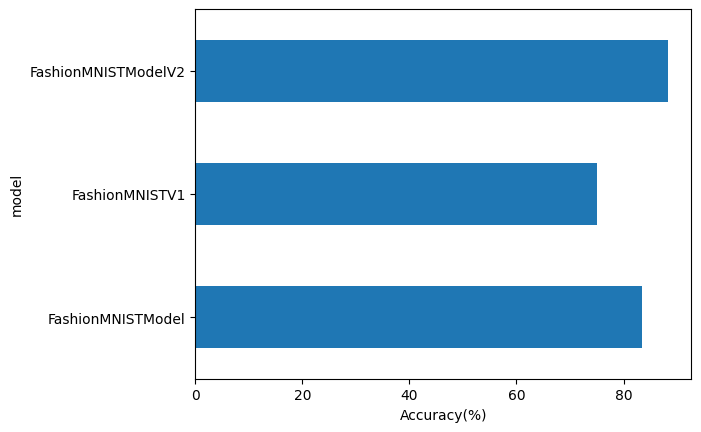

In [ ]:
# Visualizing model results
compare_results.set_index('model_name')['model_acc'].plot(kind='barh')
plt.xlabel('Accuracy(%)')
plt.ylabel('model');

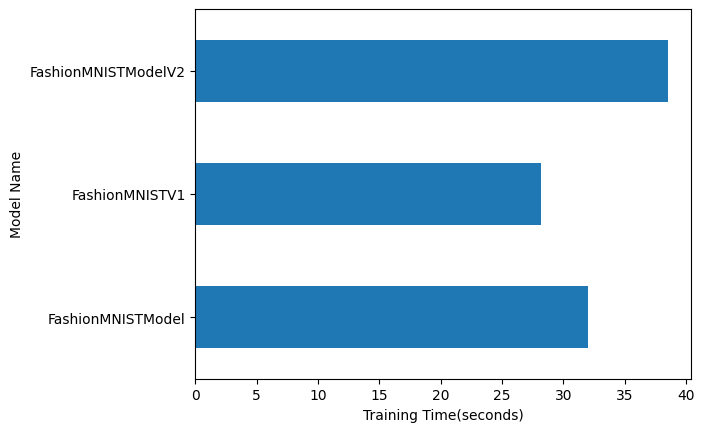

In [ ]:
compare_results.set_index('model_name')['Total_training_time'].plot(kind='barh')
plt.xlabel('Training Time(seconds)')
plt.ylabel('Model Name');

# Make and evaluate random predictions with the best model

In [ ]:
def make_prediction(model:nn.Module, data:list,
                    device:torch.device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #prepare sample(adding a batch dimension and pass to target device)
      sample = torch.unsqueeze(sample, dim=0).to(device)
      # forward pass(logits)
      pred_logit = model(sample)

      # logits -> prediction probabilities
      pred_prob = torch.softmax(pred_logit, dim=1)

      # Get pred_prob off the GPU for plot
      pred_probs.append(pred_prob)

  #stack the pred probs that is list into tensors
  return torch.stack(pred_probs)

In [ ]:
img, label = test_data[1][:10]
img.shape, label

(torch.Size([1, 28, 28]), 2)

In [ ]:
import random
samp = random.sample(list(test_data), k=9)
len(samp)

9

In [ ]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

  #view the sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

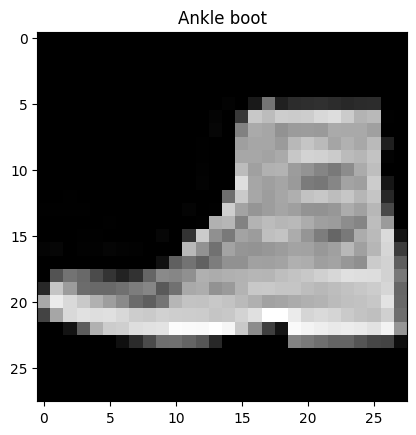

In [ ]:
plt.imshow(test_samples[0].squeeze(), cmap='gray')
plt.title(class_name[test_labels[0]]);

In [ ]:
# Make predictions
pred_probs = make_prediction(model=model_2,
                             data=test_samples)

#viewing first two prediction probbailities
pred_probs[:2], pred_probs.shape

(tensor([[[1.2636e-07, 2.6426e-08, 6.4403e-08, 9.0127e-08, 2.3210e-08,
           5.8594e-05, 1.5296e-07, 1.0543e-03, 5.2432e-06, 9.9888e-01]],
 
         [[2.7876e-04, 1.3116e-06, 5.0248e-04, 3.6952e-03, 1.6540e-04,
           7.9350e-04, 7.2566e-04, 6.3062e-06, 9.9383e-01, 2.1002e-06]]],
        device='cuda:0'),
 torch.Size([9, 1, 10]))

In [ ]:
# convert prediction probabalities -> labels
pred_label = pred_probs.squeeze().argmax(dim=1)
pred_label

tensor([9, 8, 1, 4, 1, 3, 1, 4, 6], device='cuda:0')

In [ ]:
test_labels

[9, 8, 1, 4, 1, 3, 1, 4, 6]

In [ ]:
len(test_samples)

9

In [ ]:
class_name


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
for i in range(len(pred_label)):
  print(class_name[test_labels[i]])

Ankle boot
Bag
Trouser
Coat
Trouser
Dress
Trouser
Coat
Shirt


In [ ]:
for i , sample in enumerate(test_samples):
  pred_class = class_name[pred_label[i]]
  print(pred_class)

Ankle boot
Bag
Trouser
Coat
Trouser
Dress
Trouser
Coat
Shirt


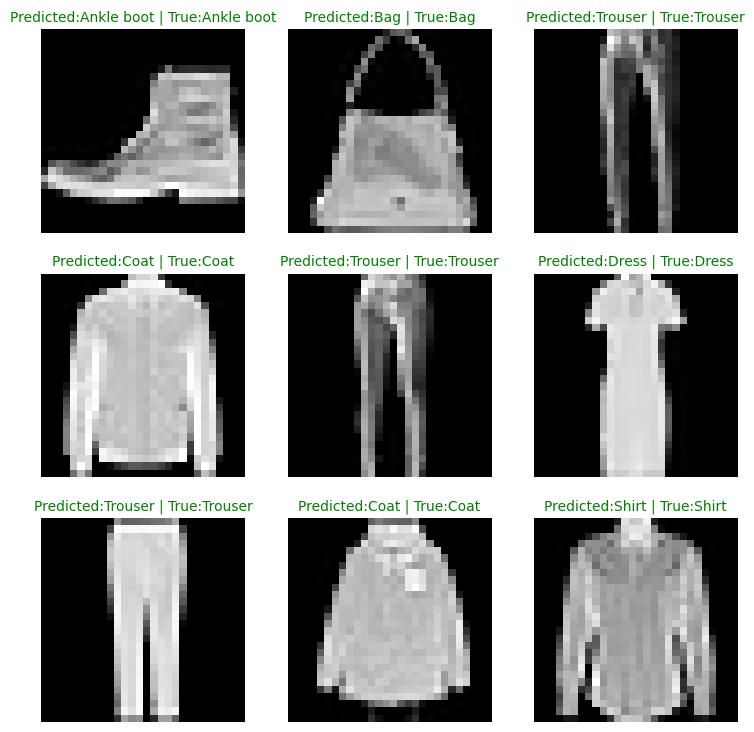

In [ ]:
# plotting the prediction labels and original labels
fig = plt.figure(figsize=(9,9))
for i, sample in enumerate(test_samples):
  #creating subplot
  plt.subplot(3,3,i+1)

  #creating imshow plot for image sample
  plt.imshow(sample.squeeze(), cmap='gray')

  #predition class with class name
  pred_class = class_name[pred_label[i]]

  #true class with class name
  true_class = class_name[test_labels[i]]

  #creating a title
  title_text = f'Predicted:{pred_class} | True:{true_class}'

  plt.axis(False)

  #check for equality between predicted and truth and change colour of title text
  if pred_class == true_class:
    plt.title(title_text, fontsize=10, c='g')
  else:
    plt.title(title_text, fontsize=10, c='r')



## 6. Confusion Matrix for furthur classification
A confusion matrix is used for evaluating the classification models visually

1. Make predictions with trained model on test dataset
2. Make confusion matrix using `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxtend.plotting.plot`

In [ ]:
import mlxtend
mlxtend.__version__

'0.23.4'

In [ ]:
#import tqdm.auto
from tqdm.auto import tqdm

#1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_loader, desc='Making Predictions....'):
    X , y = X.to(device), y.to(device)
    # Do Forward pass
    y_logits = model_2(X)
    #Turn the logits to prediction probabilities -> prediction labels
    y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1)
    #puting prediction on cpu
    y_preds.append(y_pred.cpu())

#concatenate list of predictions into tensors
# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making Predictions....:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 8])

In [ ]:
len(y_pred_tensor)

10000

In [ ]:
try:
  import torchmetrics, mlxtend
  print(f'mlxtend version:{mlxtend.__version__.split()}')
except:
  !pip install  torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f'Torchmterics Version{torchmetrics.__version__} and mlxtend version{mlxtend.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 835.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

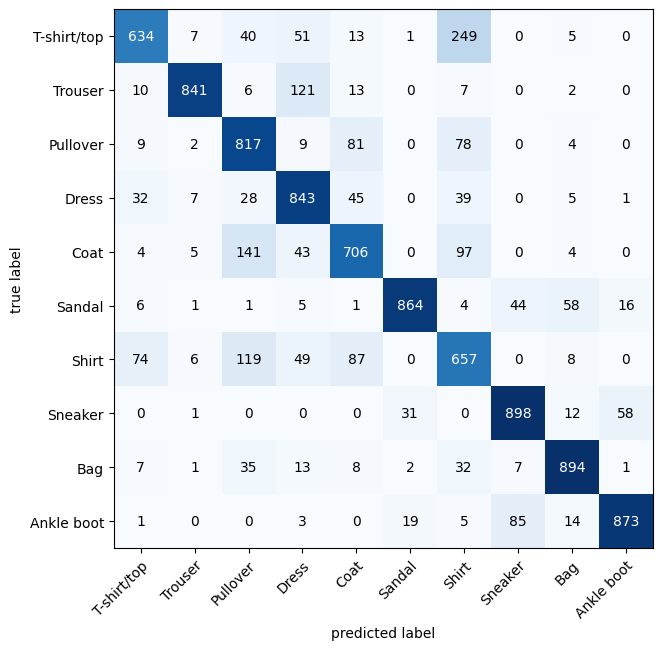

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Set up confusion matrix instance
confmat = ConfusionMatrix(num_classes=len(class_name), task='MULTICLASS')
comfat_tensor = confmat(preds=y_pred_tensor,
                        target=test_data.targets)

# 3. plotting the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=comfat_tensor.numpy(),
    class_names=class_name,
    figsize=(10,7))

In [ ]:
comfat_tensor, comfat_tensor.shape

(tensor([[634,   7,  40,  51,  13,   1, 249,   0,   5,   0],
         [ 10, 841,   6, 121,  13,   0,   7,   0,   2,   0],
         [  9,   2, 817,   9,  81,   0,  78,   0,   4,   0],
         [ 32,   7,  28, 843,  45,   0,  39,   0,   5,   1],
         [  4,   5, 141,  43, 706,   0,  97,   0,   4,   0],
         [  6,   1,   1,   5,   1, 864,   4,  44,  58,  16],
         [ 74,   6, 119,  49,  87,   0, 657,   0,   8,   0],
         [  0,   1,   0,   0,   0,  31,   0, 898,  12,  58],
         [  7,   1,  35,  13,   8,   2,  32,   7, 894,   1],
         [  1,   0,   0,   3,   0,  19,   5,  85,  14, 873]]),
 torch.Size([10, 10]))

## Save and load the best performing model

In [ ]:
#saving
from pathlib import Path
model_path = Path('models')
model_path.mkdir(parents=True, exist_ok=True)
model_name = 'FashionMNIST_model.pth'
save_path = model_path / model_name
torch.save(obj=model_2.state_dict(),f=save_path)

In [ ]:
#loading
load_FMNIST = FashionMNISTModelV2(input_shape=1,
                                  hidden_units=10,
                                  output_shape=len(class_name))
load_FMNIST.load_state_dict(torch.load(f=save_path))

# target device
load_FMNIST.to(device)


FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3273661434650421,
 'model_acc': 88.2488021850586}

In [ ]:
#Evaluate loaded model
load_model_results = eval_model(model=load_FMNIST,
                                data_loader=test_loader, device=device,
                                loss_fn=loss_fn, accuracy_fn=accuracy_fn)
load_model_results


  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3273661434650421,
 'model_acc': 88.2488021850586}

In [ ]:
# check if model results are close to each other
torch.isclose(torch.tensor(model_2_results['model_loss']),
              torch.tensor(load_model_results['model_loss']),
              atol=1e-02)

tensor(True)